In [250]:
import matplotlib.pyplot as plt # visualization
import numpy as np
import pandas as pd
import random
import seaborn as sns # visualization
from statsmodels.graphics.gofplots import qqplot # visualization
from sklearn.impute import SimpleImputer
from scipy import stats
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

# just to jupyter notebook be capable of execute matplotlib
%matplotlib inline

from pandas.plotting import register_matplotlib_converters # avoid erros between pandas and matplotlib
register_matplotlib_converters()

## Importing and cleaning our dataset

In [209]:
part2_data = pd.read_excel('C:/Users/PURITY/Documents/Jobs/python project/Contraceptive_method_dataset.xlsx')
# Process the data using pandas methods
part2_data.head(5)

,Wife_age,Wife_ education,Husband_education,No_of_children_born,Wife_religion,Wife_Working,Husband_Occupation,Standard_of_living_index,Media_exposure,Contraceptive_method_used
0,24.0,Primary,Secondary,3.0,Scientology,No,2,High,Exposed,No
1,45.0,Uneducated,Secondary,10.0,Scientology,No,3,Very High,Exposed,No
2,43.0,Primary,Secondary,7.0,Scientology,No,3,Very High,Exposed,No
3,42.0,Secondary,Primary,9.0,Scientology,No,3,High,Exposed,No
4,36.0,Secondary,Secondary,8.0,Scientology,No,3,Low,Exposed,No


In [210]:
# Seeing dataset structure
part2_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Wife_age                   1402 non-null   float64
 1   Wife_ education            1473 non-null   object 
 2   Husband_education          1473 non-null   object 
 3   No_of_children_born        1452 non-null   float64
 4   Wife_religion              1473 non-null   object 
 5   Wife_Working               1473 non-null   object 
 6   Husband_Occupation         1473 non-null   int64  
 7   Standard_of_living_index   1473 non-null   object 
 8   Media_exposure             1473 non-null   object 
 9   Contraceptive_method_used  1473 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 115.2+ KB


In [211]:
# seeing dataset shape
part2_data.shape

(1473, 10)

In [212]:
# Seeing columns
part2_data.describe()

,Wife_age,No_of_children_born,Husband_Occupation
count,1402.000000,1452.000000,1473.000000
mean,32.606277,3.254132,2.137814
std,8.274927,2.365212,0.864857
min,16.000000,0.000000,1.000000
25%,26.000000,1.000000,1.000000
50%,32.000000,3.000000,2.000000
75%,39.000000,4.000000,3.000000
max,49.000000,16.000000,4.000000


### Missing Value Analysis

<AxesSubplot:>

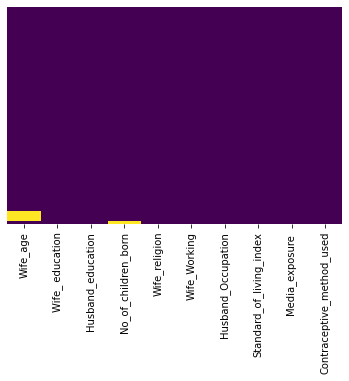

In [213]:
#Lets find out the missing data in our data set
#This heatmap shows the null values in yellow line.
sns.heatmap(part2_data.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')

In [214]:
# Compute the mean of "rchar" and "wchar"
wife_age_mean = part2_data['Wife_age'].mean()
no_children_mean = part2_data['No_of_children_born'].mean()

# Replace missing values with the mean
part2_data['Wife_age'].fillna(wife_age_mean, inplace=True)
part2_data['No_of_children_born'].fillna(no_children_mean, inplace=True)

<AxesSubplot:>

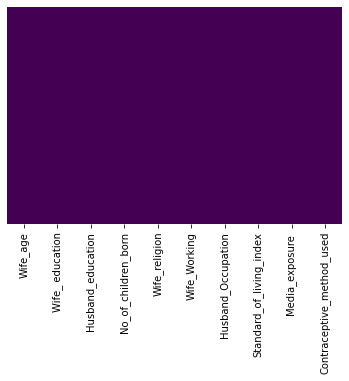

In [215]:
# # Checking if missing values still exist
# This heatmap shows the null values in yellow line.
sns.heatmap(part2_data.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')

### Exploratory Data Analysis

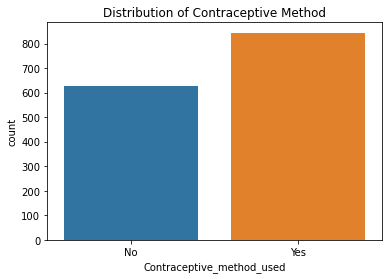

In [216]:
# Distribution of the Contraceptive_method_used variable
sns.countplot(x="Contraceptive_method_used", data=part2_data)
plt.title("Distribution of Contraceptive Method")
plt.show()

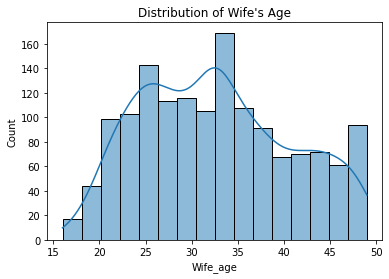

In [217]:
# Distribution of wife's age
sns.histplot(data=part2_data, x= "Wife_age", kde=True)
plt.title("Distribution of Wife's Age")
plt.show()

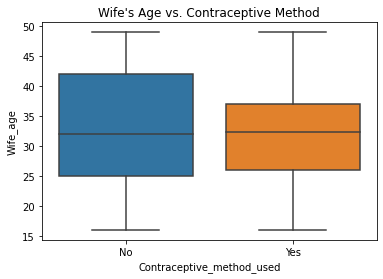

In [218]:
# Relationship between wife's age and contraceptive method
sns.boxplot(x="Contraceptive_method_used", y="Wife_age", data=part2_data)
plt.title("Wife's Age vs. Contraceptive Method")
plt.show()

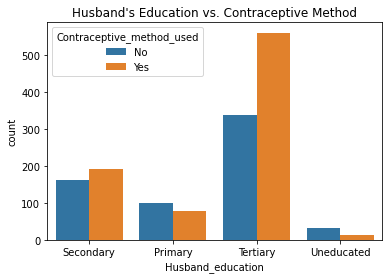

In [219]:
# Relationship between husband's education and contraceptive method
sns.countplot(x="Husband_education", hue="Contraceptive_method_used", data=part2_data)
plt.title("Husband's Education vs. Contraceptive Method")
plt.show()



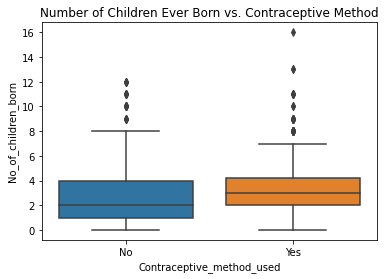

In [220]:
# Relationship between number of children ever born and contraceptive method
sns.boxplot(x="Contraceptive_method_used", y="No_of_children_born", data=part2_data)
plt.title("Number of Children Ever Born vs. Contraceptive Method")
plt.show()




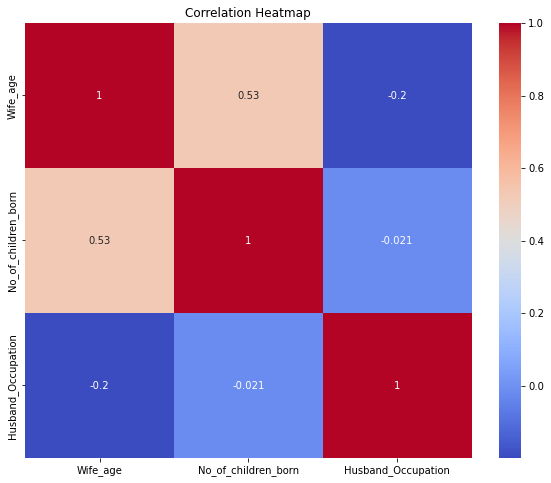

In [221]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(part2_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Now lets create dummy varibles for the categorical columns.

In [222]:
# Converting Wife_ education into a continuos variable
part2_data['Wife_ education'][part2_data['Wife_ education']=='Secondary'] = 2
part2_data['Wife_ education'][part2_data['Wife_ education']=='Tertiary'] = 3
part2_data['Wife_ education'][part2_data['Wife_ education']=='Uneducated'] = 0 
part2_data['Wife_ education'][part2_data['Wife_ education']=='Primary'] = 1

In [223]:
# Converting Husband_education into a continuos variable
part2_data['Husband_education'][part2_data['Husband_education']=='Secondary'] = 2
part2_data['Husband_education'][part2_data['Husband_education']=='Tertiary'] = 3
part2_data['Husband_education'][part2_data['Husband_education']=='Uneducated'] = 0 
part2_data['Husband_education'][part2_data['Husband_education']=='Primary'] = 1

In [224]:
# Converting Wife_Working into a continuos variable
part2_data['Wife_Working'][part2_data['Wife_Working']=='Yes'] = 1
part2_data['Wife_Working'][part2_data['Wife_Working']=='No'] = 0

In [225]:
# Converting Standard_of_living_index into a continuos variable
part2_data['Standard_of_living_index'][part2_data['Standard_of_living_index']=='Low'] = 1
part2_data['Standard_of_living_index'][part2_data['Standard_of_living_index']=='Very Low'] = 0
part2_data['Standard_of_living_index'][part2_data['Standard_of_living_index']=='High'] = 2 
part2_data['Standard_of_living_index'][part2_data['Standard_of_living_index']=='Very High'] = 3

In [226]:
# Converting Wife_religion into a continuos variable
part2_data['Wife_religion'][part2_data['Wife_religion']=='Scientology'] = 1
part2_data['Wife_religion'][part2_data['Wife_religion']=='Non-Scientology'] = 0

In [227]:
# Converting Contraceptive_method_used into a continuos variable
part2_data['Contraceptive_method_used'][part2_data['Contraceptive_method_used']=='Yes'] = 1
part2_data['Contraceptive_method_used'][part2_data['Contraceptive_method_used']=='No'] = 0

In [228]:
# Converting Media_exposure into a continuos variable
part2_data['Media_exposure '][part2_data['Media_exposure ']=='Exposed'] = 1
part2_data['Media_exposure '][part2_data['Media_exposure ']=='Not-Exposed'] = 0

In [229]:
part2_data.head(5)

,Wife_age,Wife_ education,Husband_education,No_of_children_born,Wife_religion,Wife_Working,Husband_Occupation,Standard_of_living_index,Media_exposure,Contraceptive_method_used
0,24.0,1,2,3.0,1,0,2,2,1,0
1,45.0,0,2,10.0,1,0,3,3,1,0
2,43.0,1,2,7.0,1,0,3,3,1,0
3,42.0,2,1,9.0,1,0,3,2,1,0
4,36.0,2,2,8.0,1,0,3,1,1,0


In [230]:
part2_data['Contraceptive_method_used'].astype(int)

0       0
1       0
2       0
3       0
4       0
       ..
1468    1
1469    1
1470    1
1471    1
1472    1
Name: Contraceptive_method_used, Length: 1473, dtype: int32

# Modeling

# Logistic Regression

Logistic regression assumes a Gaussian distribution for the numeric input variables and can model binary classification problems. You can construct a logistic regression model using the LogisticRegression clas

In [252]:
#Now lets train our model to do predictions.
#For that first we need to divide our data set in two datasets
X=part2_data.drop('Contraceptive_method_used', axis = 1)
y= part2_data['Contraceptive_method_used']

In [253]:
# splitting our dataset into train and target
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size = 0.3, random_state=42)

In [254]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Convert y_train to integer array
y_train = y_train.astype(int)

# Convert y_test to integer array
y_test = y_test.astype(int)


In [255]:
# Create an instance of the Logistic Regression model
logmodel = LogisticRegression()

In [256]:

# Fit the model with the encoded labels
logmodel.fit(X_train, y_train)

LogisticRegression()

In [257]:
# Make predictions on the test set
predictions = logmodel.predict(X_test)


In [258]:
# Convert predictions to integer array
predictions = predictions.astype(int)

# Print classification report and confusion matrix
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))


              precision    recall  f1-score   support

           0       0.66      0.46      0.54       194
           1       0.66      0.81      0.73       248

    accuracy                           0.66       442
   macro avg       0.66      0.64      0.63       442
weighted avg       0.66      0.66      0.65       442

[[ 89 105]
 [ 46 202]]


# Decision Tree (CART)

Classification and Regression Trees (CART or just decision trees) construct a binary tree from the training data. Split points are chosen greedily by evaluating each attribute and each value of each attribute in the training data in order to minimize a cost function (like the Gini index).

In [248]:
## Decision Tree

Model = DecisionTreeClassifier()
Model.fit(X_train, y_train)
y_pred = Model.predict(X_test)

# Summary of the predictions made by the classifier
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
# Accuracy score

print('accuracy is',accuracy_score(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.61      0.68      0.64       194
           1       0.72      0.66      0.69       248

    accuracy                           0.67       442
   macro avg       0.67      0.67      0.67       442
weighted avg       0.67      0.67      0.67       442

[[131  63]
 [ 84 164]]
accuracy is 0.667420814479638


# Linear Discriminant Analysis

Linear Discriminant Analysis or LDA is a statistical technique for binary and multiclass classification. It too assumes a Gaussian distribution for the numerical input variables.

In [251]:
# Linear Discriminant Analysis

Model = LinearDiscriminantAnalysis()
Model.fit(X_train, y_train)

y_pred = Model.predict(X_test)

# Summary of the predictions made by the classifier
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
# Accuracy score

print('accuracy is',accuracy_score(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.67      0.46      0.55       194
           1       0.66      0.83      0.73       248

    accuracy                           0.67       442
   macro avg       0.67      0.64      0.64       442
weighted avg       0.67      0.67      0.65       442

[[ 89 105]
 [ 43 205]]
accuracy is 0.665158371040724
